# Title :  Explainable deep learning for brain tumour classification in MRI images using Grad-CAM

# Libraries Import and Deep Learning Environment Setup

In [1]:
# I suppressed all unnecessary warnings to keep the output clean
import warnings
warnings.filterwarnings('ignore')

# I enabled mixed precision to speed up training and reduce GPU memory usage
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

# I imported libraries required for file handling and hashing
import zipfile
import hashlib
import os
import uuid
import re
import random
import shutil
from pathlib import Path

# I imported libraries for visualization and data analysis
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# I imported image processing libraries
import cv2
import numpy as np
from PIL import Image, ImageStat, UnidentifiedImageError, ImageEnhance
from matplotlib import patches
from skimage.transform import resize

# I imported progress tracking and collection utilities
from tqdm import tqdm
from collections import defaultdict, Counter

# I imported Google Colab utilities for drive mounting and file uploads
from google.colab import drive
from google.colab import files

# I imported machine learning preprocessing utilities
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# I imported TensorFlow and Keras backend
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow import keras

# I imported the pretrained InceptionV3 model and its preprocessing function
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

# I imported utilities for categorical encoding
from tensorflow.keras.utils import to_categorical

# I imported layers, models, optimizers, and regularization tools
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

# I imported optimizers for training
from tensorflow.keras.optimizers import Adam, AdamW

# I imported callbacks to control training behaviour
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# I imported functional API tools
from tensorflow.keras import Input, Model

# I imported image data preprocessing utilities
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img
from tensorflow.keras.preprocessing import image

# I imported evaluation metrics for classification performance analysis
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score,
    precision_recall_fscore_support, auc
)

# I printed the TensorFlow version to confirm the runtime environment
print(tf.__version__)

2.19.0


# Dataset Installation and Automatic Download from Kaggle

In [2]:
# I installed the kagglehub package to access Kaggle datasets programmatically
!pip -q install kagglehub

# I imported kagglehub to enable dataset downloading
import kagglehub

# I downloaded the Brain Tumor MRI dataset directly from Kaggle using kagglehub
path = kagglehub.dataset_download(
    "masoudnickparvar/brain-tumor-mri-dataset"
)

# I printed the local directory path to verify where the dataset was stored
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset downloaded to: /kaggle/input/brain-tumor-mri-dataset


# Dataset Directory Structure Verification

In [3]:
# I imported the OS module to explore the dataset directory structure
import os

# I traversed the dataset folder to check how many files existed in the first directory level
for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "files")
    break

/kaggle/input/brain-tumor-mri-dataset -> 0 files


# Dataset Loading and Preparation using TensorFlow

In [4]:
# I imported TensorFlow to create image datasets for model training
import tensorflow as tf

# I defined the input image size and batch size for training
IMG_SIZE = (224,224)
BATCH_SIZE = 32

# I loaded the training dataset from the Training directory with categorical labels
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path + "/Training",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# I loaded the validation dataset from the Testing directory
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path + "/Testing",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# I printed the detected class names to verify dataset labels
print("Classes:", train_ds.class_names)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


# Image Normalization and Performance Optimization

In [5]:
# I imported layers to apply preprocessing operations on images
from tensorflow.keras import layers

# I created a normalization layer to scale pixel values from 0–255 to 0–1
normalization_layer = layers.Rescaling(1./255)

# I applied normalization to both training and validation datasets
train_ds = train_ds.map(lambda x,y: (normalization_layer(x),y))
val_ds   = val_ds.map(lambda x,y: (normalization_layer(x),y))

# I enabled dataset prefetching to improve training performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)

# I confirmed that the dataset was ready for training
print("Dataset Ready for Training")

Dataset Ready for Training


# Creating Image Metadata DataFrame

In [6]:
# I imported required libraries to organize image file information
from pathlib import Path
import pandas as pd

# I defined valid image file formats to filter dataset files
image_extensions = {'.jpg', '.jpeg', '.png'}

# I scanned the dataset directory and collected class labels, image names, and full file paths
paths = [
    (p.parent.name, p.name, str(p))
    for p in Path(path).rglob('*.*')
    if p.suffix.lower() in image_extensions
]

# I created a dataframe to store image metadata
df = pd.DataFrame(paths, columns=['class', 'image', 'full_path'])

# I sorted the dataframe by class labels and reset the index
df = df.sort_values('class', ascending=True)
df.reset_index(drop=True, inplace=True)

# I displayed the first few records to verify correctness
df.head()

,class,image,full_path
0,glioma,Te-gl_47.jpg,/kaggle/input/brain-tumor-mri-dataset/Testing/...
1,glioma,Tr-gl_164.jpg,/kaggle/input/brain-tumor-mri-dataset/Training...
2,glioma,Tr-gl_508.jpg,/kaggle/input/brain-tumor-mri-dataset/Training...
3,glioma,Tr-gl_491.jpg,/kaggle/input/brain-tumor-mri-dataset/Training...
4,glioma,Tr-gl_118.jpg,/kaggle/input/brain-tumor-mri-dataset/Training...


# Exploratory Data Analysis

# Dataset Statistics and Image Format Analysis

In [7]:
# I imported necessary libraries to analyze dataset distribution
import os
from collections import Counter

# I counted the number of images in each class
class_count = df['class'].value_counts()

for cls, count in class_count.items():
    print(f'Class: {cls}, Count: {count} images')

# I printed the total dataset size and number of classes
print(f"\nTotal dataset size is: {len(df)} images")
print(f"Number of classes: {df['class'].nunique()} classes")

# I extracted file extensions to analyze image format distribution
extensions = [os.path.splitext(fname)[1].lower() for fname in df['image']]
ext_count = Counter(extensions)

print("\nImage format distribution:")
for ext, count in ext_count.items():
    print(f"Extension: {ext}, Count: {count} images")

Class: glioma, Count: 1800 images
Class: meningioma, Count: 1800 images
Class: notumor, Count: 1800 images
Class: pituitary, Count: 1800 images

Total dataset size is: 7200 images
Number of classes: 4 classes

Image format distribution:
Extension: .jpg, Count: 7200 images


# Class Distribution Visualization

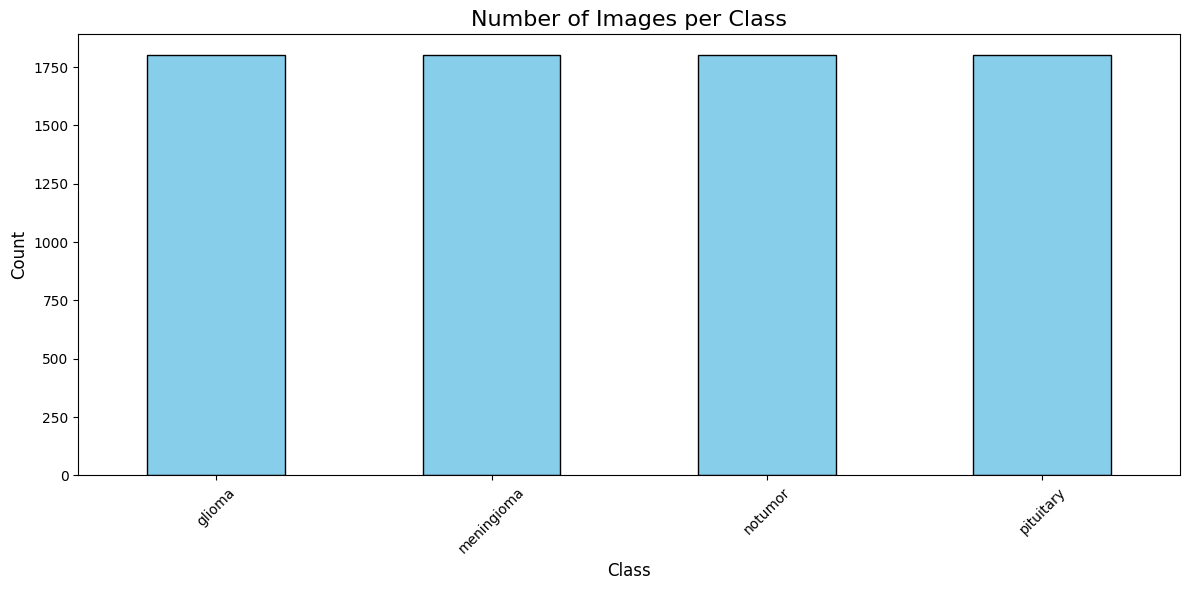

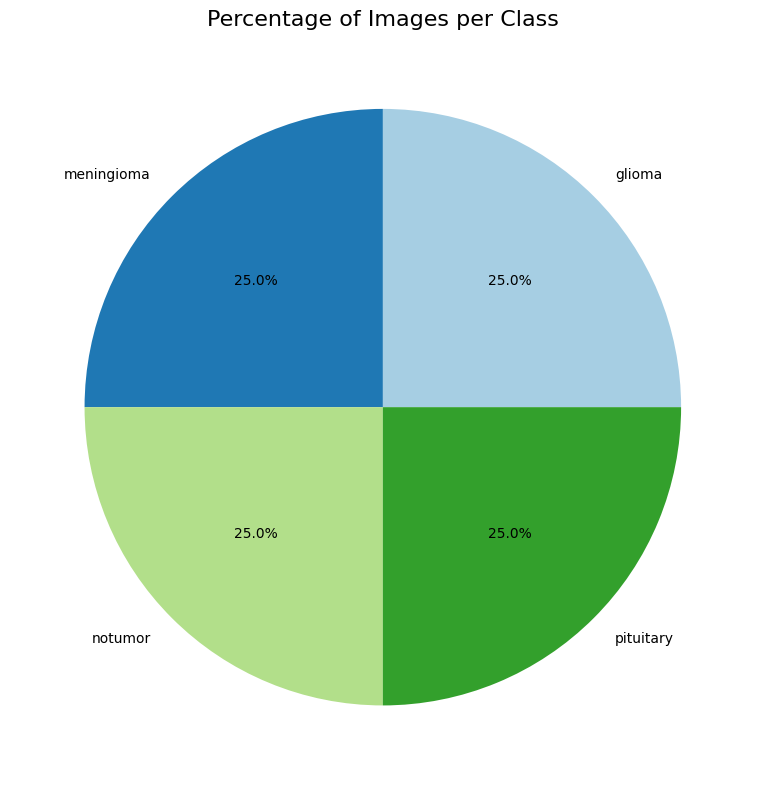

In [8]:
# I imported matplotlib to visualize dataset distribution
import matplotlib.pyplot as plt

# I recomputed the class count from the dataframe to ensure updated statistics
class_count = df['class'].value_counts()

# I plotted a bar chart to show the number of images in each class
plt.figure(figsize=(12,6))
class_count.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Images per Class', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# I plotted a pie chart to display percentage distribution of each class
plt.figure(figsize=(8,8))
class_count.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Paired.colors)

plt.title('Percentage of Images per Class', fontsize=16)
plt.ylabel('')
plt.tight_layout()
plt.show()

# Class Imbalance Analysis

            Count  Percentage %
class                          
glioma       1800          25.0
meningioma   1800          25.0
notumor      1800          25.0
pituitary    1800          25.0


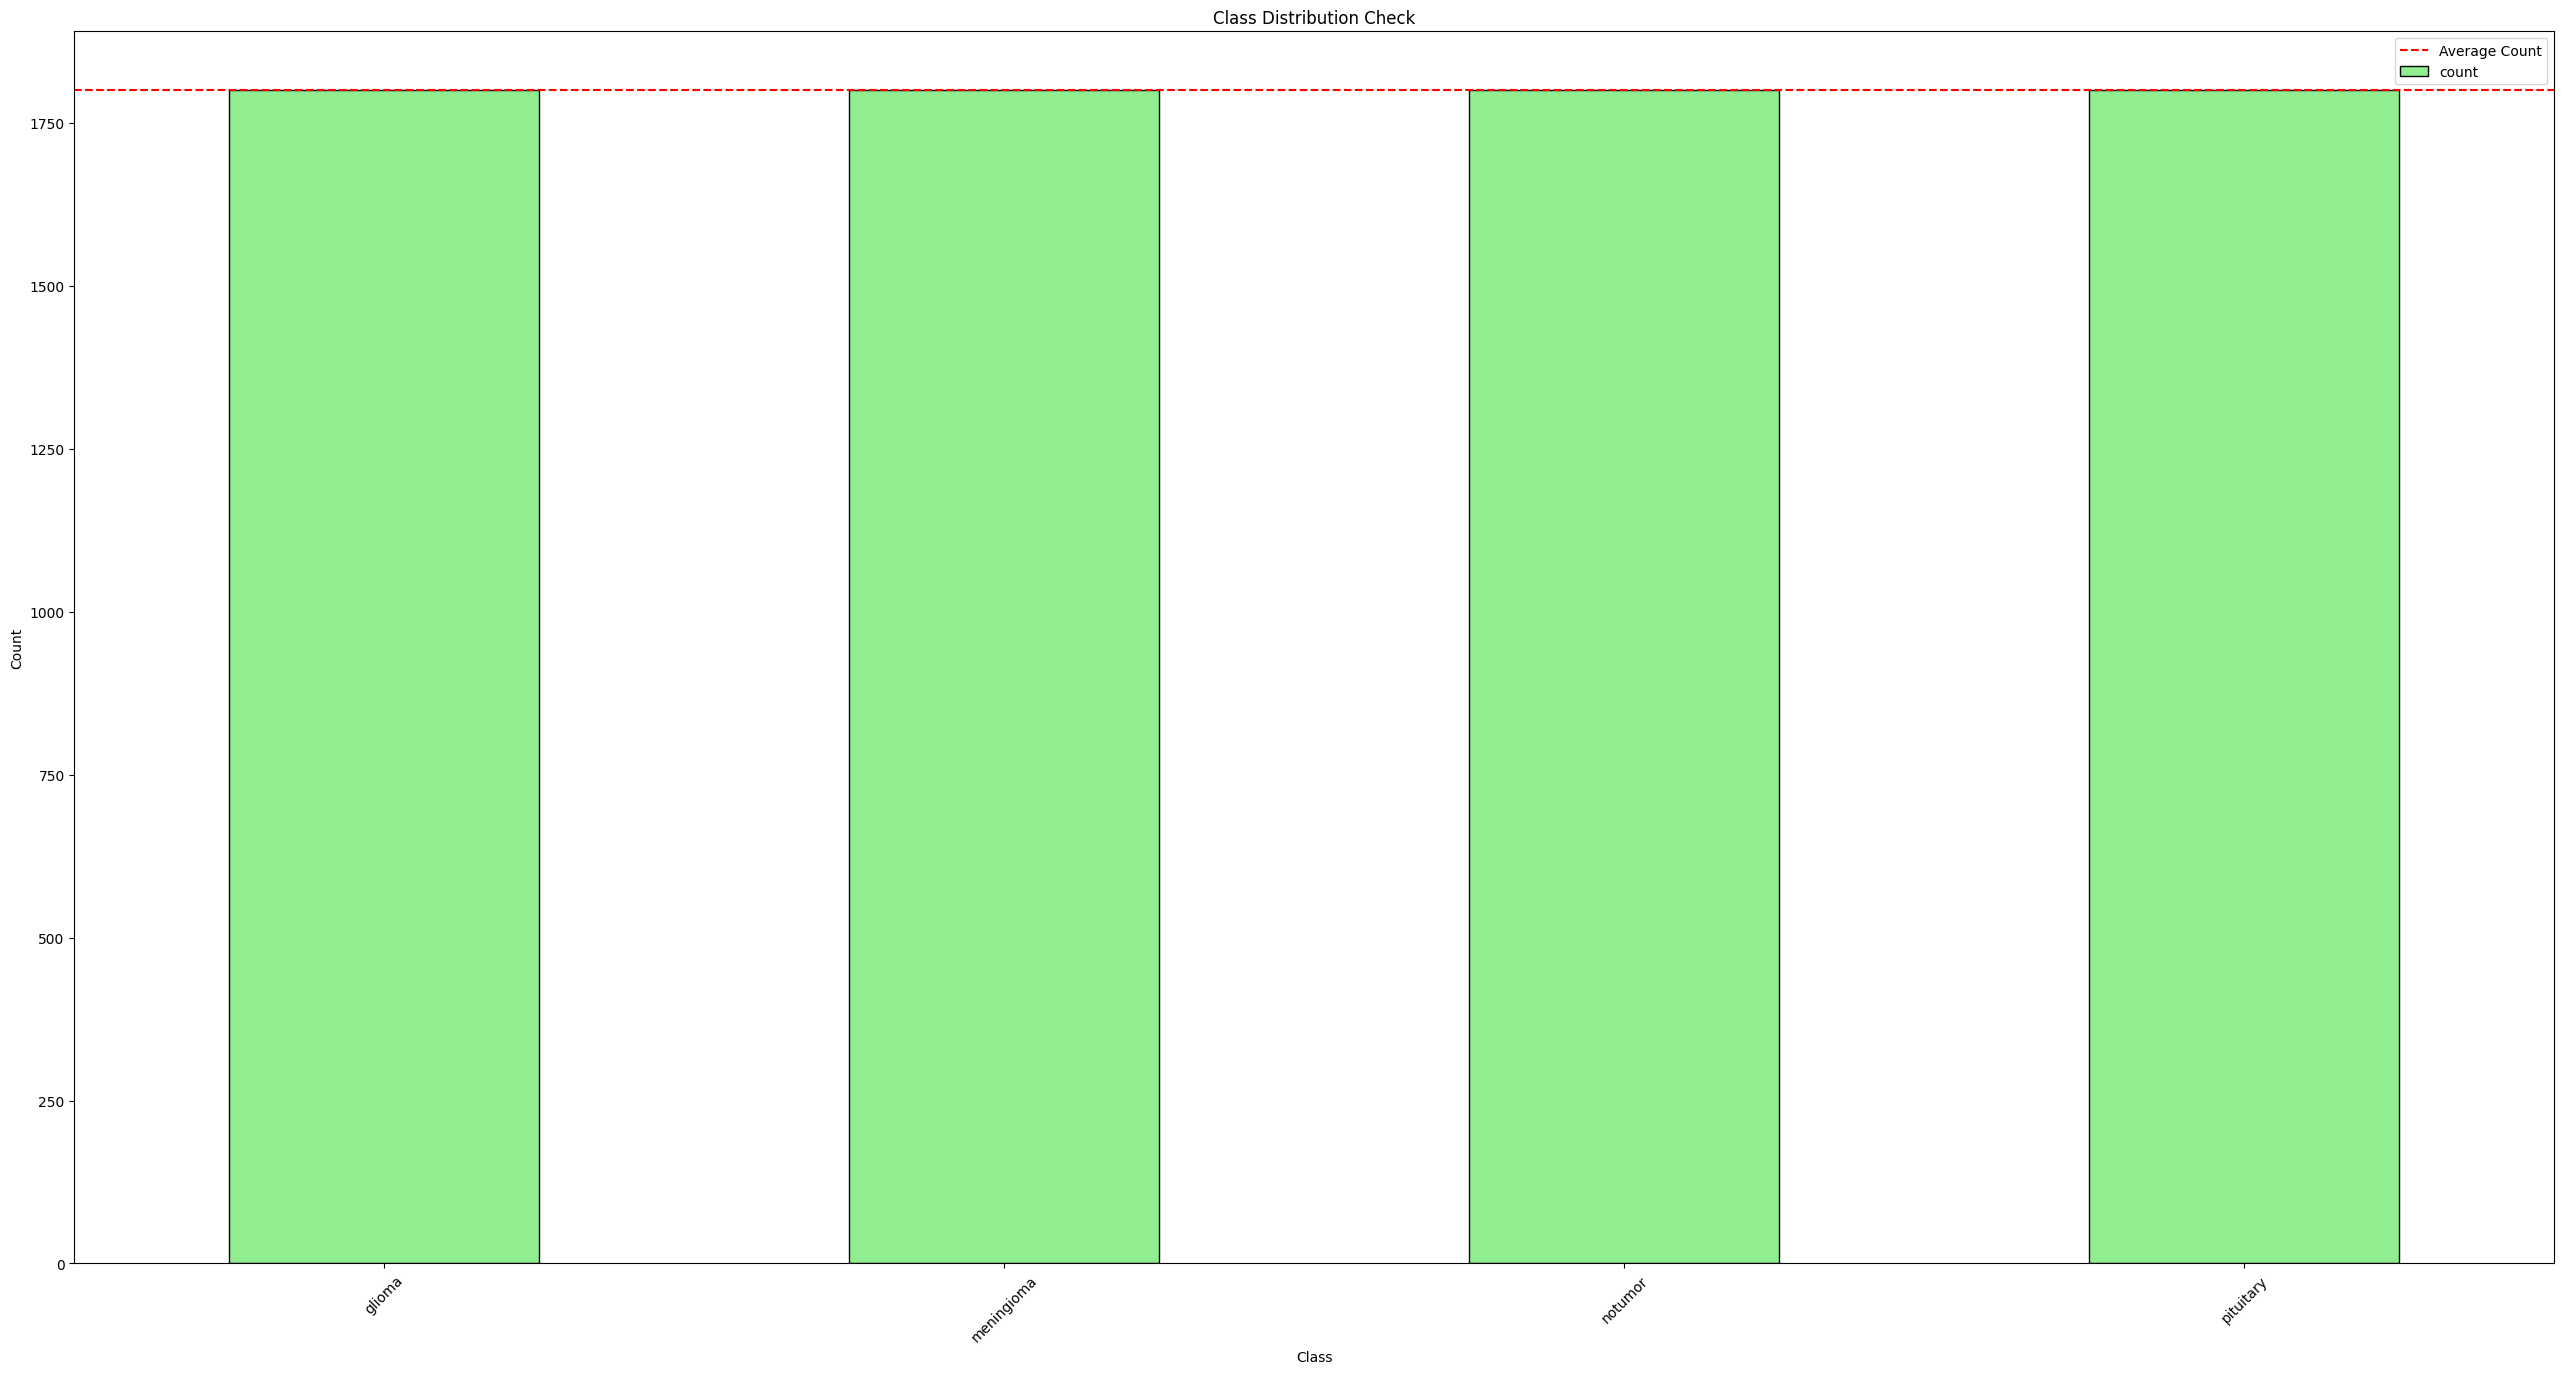

In [9]:
# I calculated the percentage of each class to analyze dataset balance
percentages = (class_count / len(df)) * 100

# I created a dataframe showing both count and percentage
imbalance_df = pd.DataFrame({'Count': class_count, 'Percentage %': percentages.round(2)})
print(imbalance_df)

# I plotted a bar chart to visually inspect class imbalance
plt.figure(figsize = (32, 16))
class_count.plot(kind = 'bar', color = 'lightgreen', edgecolor = 'black')

plt.title('Class Distribution Check')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation = 45)

# I added a horizontal line showing the average number of images per class
plt.axhline(y = class_count.mean(), color = 'red', linestyle = '--', label = 'Average Count')
plt.legend()

# Image Size and Channel Distribution Analysis

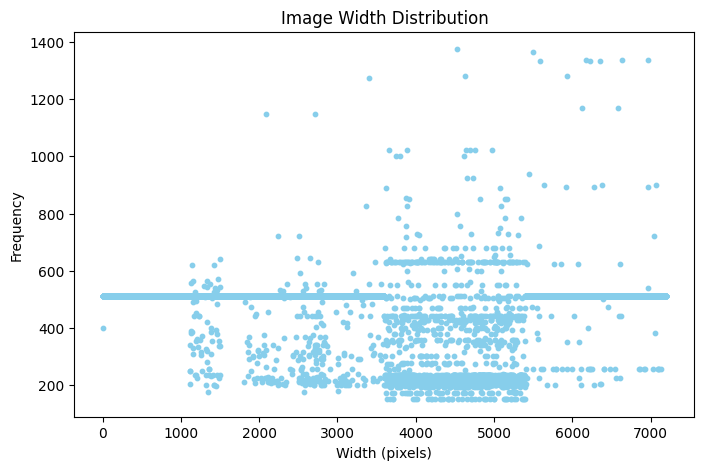

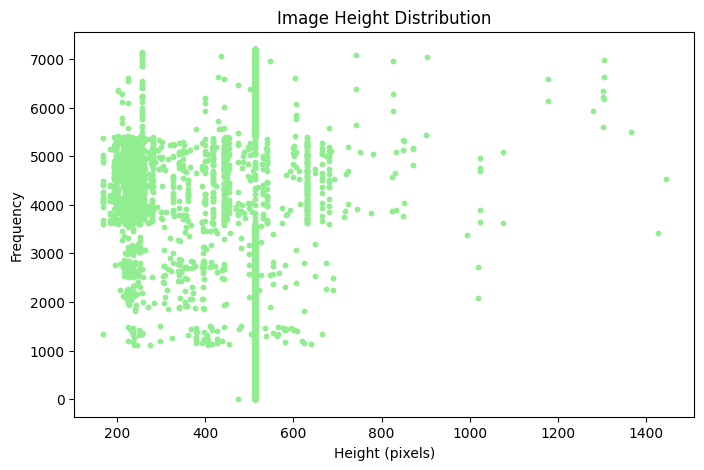

     Width  Height  Count
0      512     512   5014
1      225     225    338
2      630     630     90
3      201     251     57
4      228     221     51
..     ...     ...    ...
442   1280    1280      1
443    175     167      1
444    174     230      1
445   1365    1365      1
446   1375    1446      1

[447 rows x 3 columns]
Image Mode Distribution:
Mode
RGB     4129
L       3067
RGBA       3
P          1
Name: count, dtype: int64

Number of Channels Distribution:
Channels
3    4129
1    3068
4       3
Name: count, dtype: int64


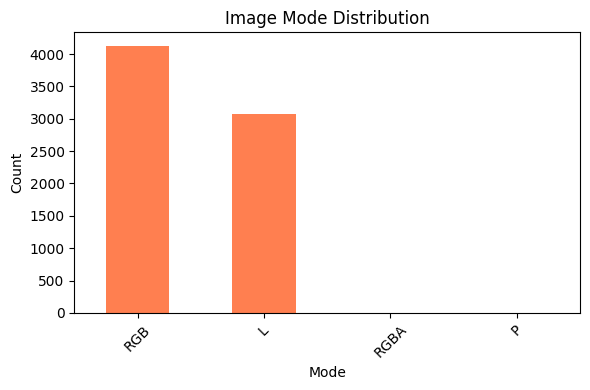

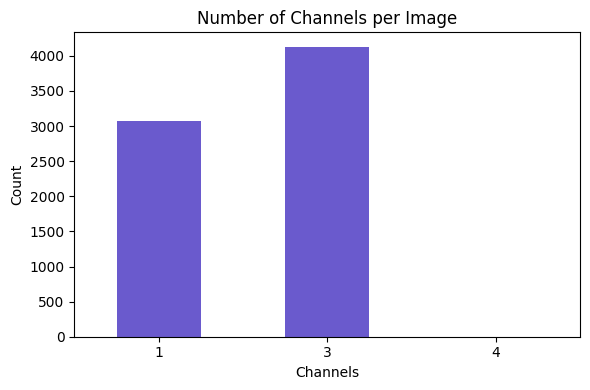

In [10]:
# I collected width and height of each image to analyze dimension variability
image_sizes = []

for file_path in df['full_path']:
    with Image.open(file_path) as img:
        image_sizes.append(img.size)

# I stored image dimensions into a dataframe
sizes_df = pd.DataFrame(image_sizes, columns=['Width', 'Height'])

# I plotted width distribution of images
plt.figure(figsize=(8,5))
plt.scatter(x = range(len(sizes_df)), y = sizes_df['Width'], color='skyblue', s=10)
plt.title('Image Width Distribution')
plt.xlabel('Width (pixels)')
plt.ylabel('Frequency')
plt.show()

# I plotted height distribution of images
plt.figure(figsize=(8,5))
plt.scatter(x = sizes_df['Height'], y = range(len(sizes_df)), color='lightgreen', s=10)
plt.title('Image Height Distribution')
plt.xlabel('Height (pixels)')
plt.ylabel('Frequency')
plt.show()

# I checked unique image size occurrences
unique_sizes = sizes_df.value_counts().reset_index(name='Count')
print(unique_sizes)

# I extracted additional image properties such as mode and channel count
image_data = []

for file_path in df['full_path']:
    with Image.open(file_path) as img:
        width, height = img.size
        mode = img.mode
        channels = len(img.getbands())
        image_data.append((width, height, mode, channels))

# I created dataframe for image characteristics
image_df = pd.DataFrame(image_data, columns=['Width', 'Height', 'Mode', 'Channels'])

# I displayed distribution of image color modes
print("Image Mode Distribution:")
print(image_df['Mode'].value_counts())

# I displayed distribution of number of channels
print("\nNumber of Channels Distribution:")
print(image_df['Channels'].value_counts())

# I plotted image mode distribution
plt.figure(figsize=(6,4))
image_df['Mode'].value_counts().plot(kind='bar', color='coral')
plt.title("Image Mode Distribution")
plt.xlabel("Mode")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# I plotted channel distribution
plt.figure(figsize=(6,4))
image_df['Channels'].value_counts().sort_index().plot(kind='bar', color='slateblue')
plt.title("Number of Channels per Image")
plt.xlabel("Channels")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Dataset Balancing using Data Augmentation

In [11]:
# I imported required libraries for file handling, augmentation, and progress tracking
import os, shutil, uuid
import numpy as np
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array,
    array_to_img
)

# I created a target directory to store the balanced dataset
balanced_dir = "/content/brain_data_balanced"
os.makedirs(balanced_dir, exist_ok=True)

# I defined augmentation transformations to increase dataset diversity
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest'
)

# I set the desired number of images per class
target_count = 2000

# I iterated through each class to balance the dataset
for cls in tqdm(sorted(df['class'].unique()), desc="Balancing classes"):

    class_df = df[df['class'] == cls]
    class_paths = class_df['full_path'].tolist()

    class_dir = os.path.join(balanced_dir, cls)
    os.makedirs(class_dir, exist_ok=True)

    # I copied original images into the new balanced directory
    for img_path in class_paths:
        new_name = os.path.basename(img_path)
        shutil.copy(img_path, os.path.join(class_dir, new_name))

    current_count = len(class_paths)

    # I skipped augmentation if class already had sufficient images
    if current_count >= target_count:
        continue

    num_to_generate = target_count - current_count
    gen_count = 0

    # I generated augmented images until reaching the target count
    while gen_count < num_to_generate:
        for img_path in class_paths:

            if gen_count >= num_to_generate:
                break

            img = load_img(img_path, target_size=(224, 224))
            x = img_to_array(img)
            x = np.expand_dims(x, axis=0)

            aug_img = next(datagen.flow(x, batch_size=1))[0]

            base = os.path.splitext(os.path.basename(img_path))[0]
            new_filename = f"aug_{base}_{uuid.uuid4().hex[:8]}.jpg"

            save_path = os.path.join(class_dir, new_filename)
            array_to_img(aug_img).save(save_path)

            gen_count += 1

# I printed the location of the balanced dataset
print("\nBalanced dataset created at:", balanced_dir)

Balancing classes: 100%|██████████| 4/4 [00:16<00:00,  4.11s/it]


Balanced dataset created at: /content/brain_data_balanced


# Balanced Dataset Metadata Preparation

In [12]:
# I filtered valid image files from the balanced dataset directory
image_extensions = {'.jpg', '.jpeg', '.png'}
paths = [
    (path.parts[-2], path.name, str(path))
    for path in Path(balanced_dir).rglob('*.*')
    if path.suffix.lower() in image_extensions
]

# I created a dataframe containing class labels and image paths
df = pd.DataFrame(paths, columns = ['class', 'image', 'full_path'])

# I sorted the dataframe and reset the index
df = df.sort_values('class', ascending = True)
df.reset_index(drop = True, inplace = True)

# I displayed the updated dataframe
df

,class,image,full_path
0,glioma,Te-gl_93.jpg,/content/brain_data_balanced/glioma/Te-gl_93.jpg
1,glioma,Tr-gl_447.jpg,/content/brain_data_balanced/glioma/Tr-gl_447.jpg
2,glioma,Tr-gl_907.jpg,/content/brain_data_balanced/glioma/Tr-gl_907.jpg
3,glioma,aug_Tr-gl_1233_af69dd1c.jpg,/content/brain_data_balanced/glioma/aug_Tr-gl_...
4,glioma,Tr-gl_920.jpg,/content/brain_data_balanced/glioma/Tr-gl_920.jpg
...,...,...,...
7995,pituitary,Te-pi_58.jpg,/content/brain_data_balanced/pituitary/Te-pi_5...
7996,pituitary,aug_Tr-pi_413_a78b8089.jpg,/content/brain_data_balanced/pituitary/aug_Tr-...
7997,pituitary,Tr-pi_141.jpg,/content/brain_data_balanced/pituitary/Tr-pi_1...
7998,pituitary,Te-pi_301.jpg,/content/brain_data_balanced/pituitary/Te-pi_3...


# Balanced Dataset Statistics Verification

In [13]:
# I counted the number of images per class in the balanced dataset
class_count = df['class'].value_counts()
for cls, count in class_count.items():
    print(f'Class: {cls}, Count: {count} images')

# I printed total dataset size and number of classes
print(f"\nTotal dataset size is: {len(df)} images")
print(f"Number of classes: {df['class'].nunique()} classes")

# I analyzed the distribution of image file formats
extensions = [os.path.splitext(fname)[1].lower() for fname in df['image']]
ext_count = Counter(extensions)

print("\nImage format distribution:")
for ext, count in ext_count.items():
    print(f"Extension: {ext}, Count: {count} images")

Class: glioma, Count: 2000 images
Class: meningioma, Count: 2000 images
Class: notumor, Count: 2000 images
Class: pituitary, Count: 2000 images

Total dataset size is: 8000 images
Number of classes: 4 classes

Image format distribution:
Extension: .jpg, Count: 8000 images


# Original vs Augmented Image Visualization

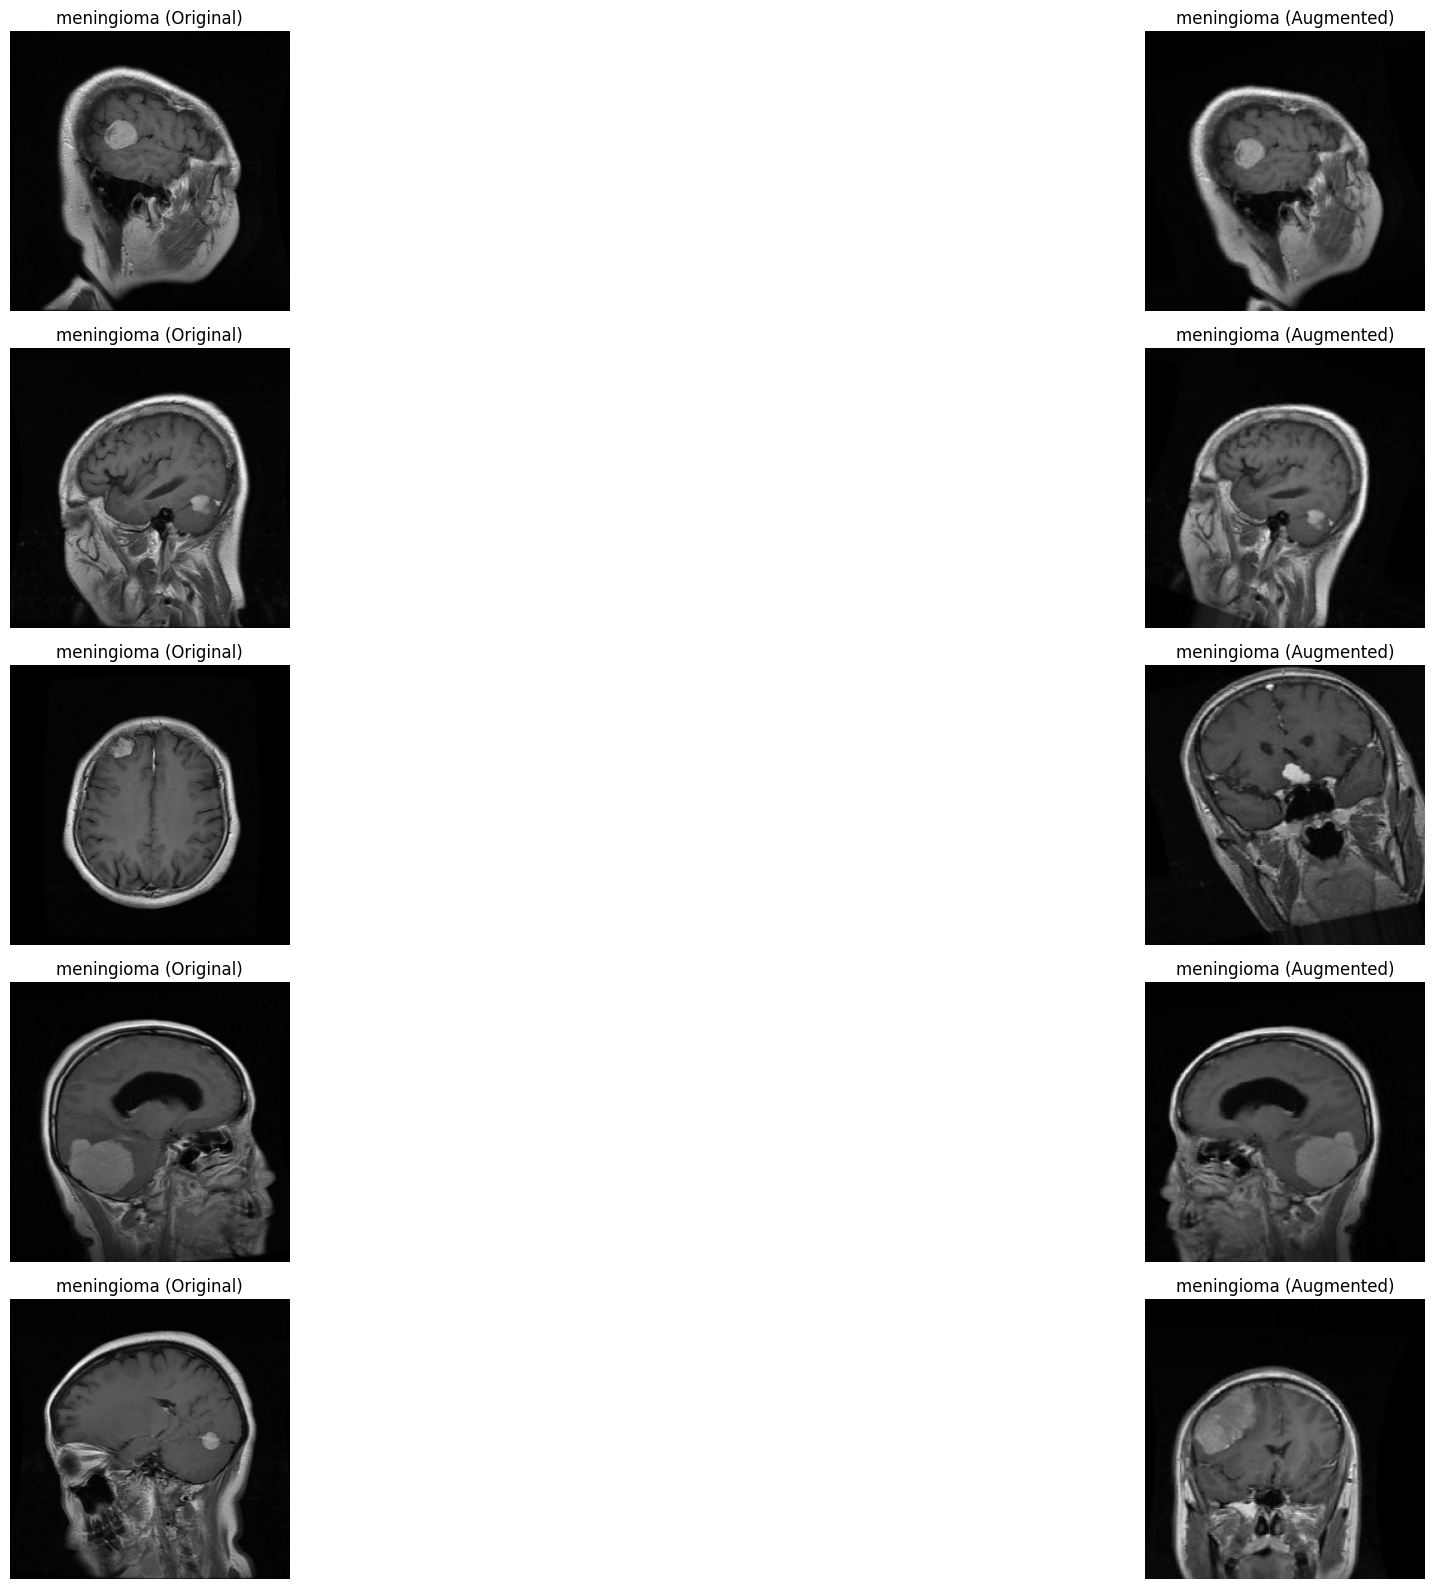

In [14]:
# I randomly selected a class to visualize augmentation results
random_class = random.choice(df['class'].unique())
class_df = df[df['class'] == random_class]

# I mapped original images to their corresponding augmented versions
pairs = []
for orig_path in class_df[~class_df['image'].str.startswith("aug_")]['full_path']:
    base_name = os.path.splitext(os.path.basename(orig_path))[0]
    related_augs = class_df[class_df['image'].str.contains(f"aug_{base_name}")]['full_path'].tolist()
    if related_augs:
        pairs.append((orig_path, random.choice(related_augs)))

# I selected up to five original–augmented image pairs
pairs = random.sample(pairs, min(5, len(pairs)))

# I displayed original and augmented images side by side
plt.figure(figsize=(32, 16))
for i, (orig, aug) in enumerate(pairs):
    plt.subplot(len(pairs), 2, 2*i+1)
    plt.imshow(Image.open(orig).convert("RGB"))
    plt.title(f"{random_class} (Original)")
    plt.axis("off")

    plt.subplot(len(pairs), 2, 2*i+2)
    plt.imshow(Image.open(aug).convert("RGB"))
    plt.title(f"{random_class} (Augmented)")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Sample Image Quality Inspection

Image: Tr-me_117.jpg | Class: meningioma | Size: 512x512 | Brightness: 41.9 | Contrast: 40.2
Image: Tr-me_1298.jpg | Class: meningioma | Size: 512x512 | Brightness: 34.6 | Contrast: 45.8
Image: Tr-gl_193.jpg | Class: glioma | Size: 512x512 | Brightness: 22.5 | Contrast: 30.4
Image: Te-me_197.jpg | Class: meningioma | Size: 442x442 | Brightness: 46.2 | Contrast: 37.1
Image: Tr-no_23.jpg | Class: notumor | Size: 359x449 | Brightness: 43.4 | Contrast: 40.1
Image: Tr-me_1255.jpg | Class: meningioma | Size: 512x512 | Brightness: 30.7 | Contrast: 45.3
Image: Tr-gl_1099.jpg | Class: glioma | Size: 512x512 | Brightness: 26.0 | Contrast: 33.6
Image: Te-gl_229.jpg | Class: glioma | Size: 495x619 | Brightness: 78.6 | Contrast: 62.3
Image: aug_Tr-no_1180_a5367e66.jpg | Class: notumor | Size: 224x224 | Brightness: 45.4 | Contrast: 57.3
Image: Tr-me_250.jpg | Class: meningioma | Size: 512x512 | Brightness: 47.2 | Contrast: 40.8


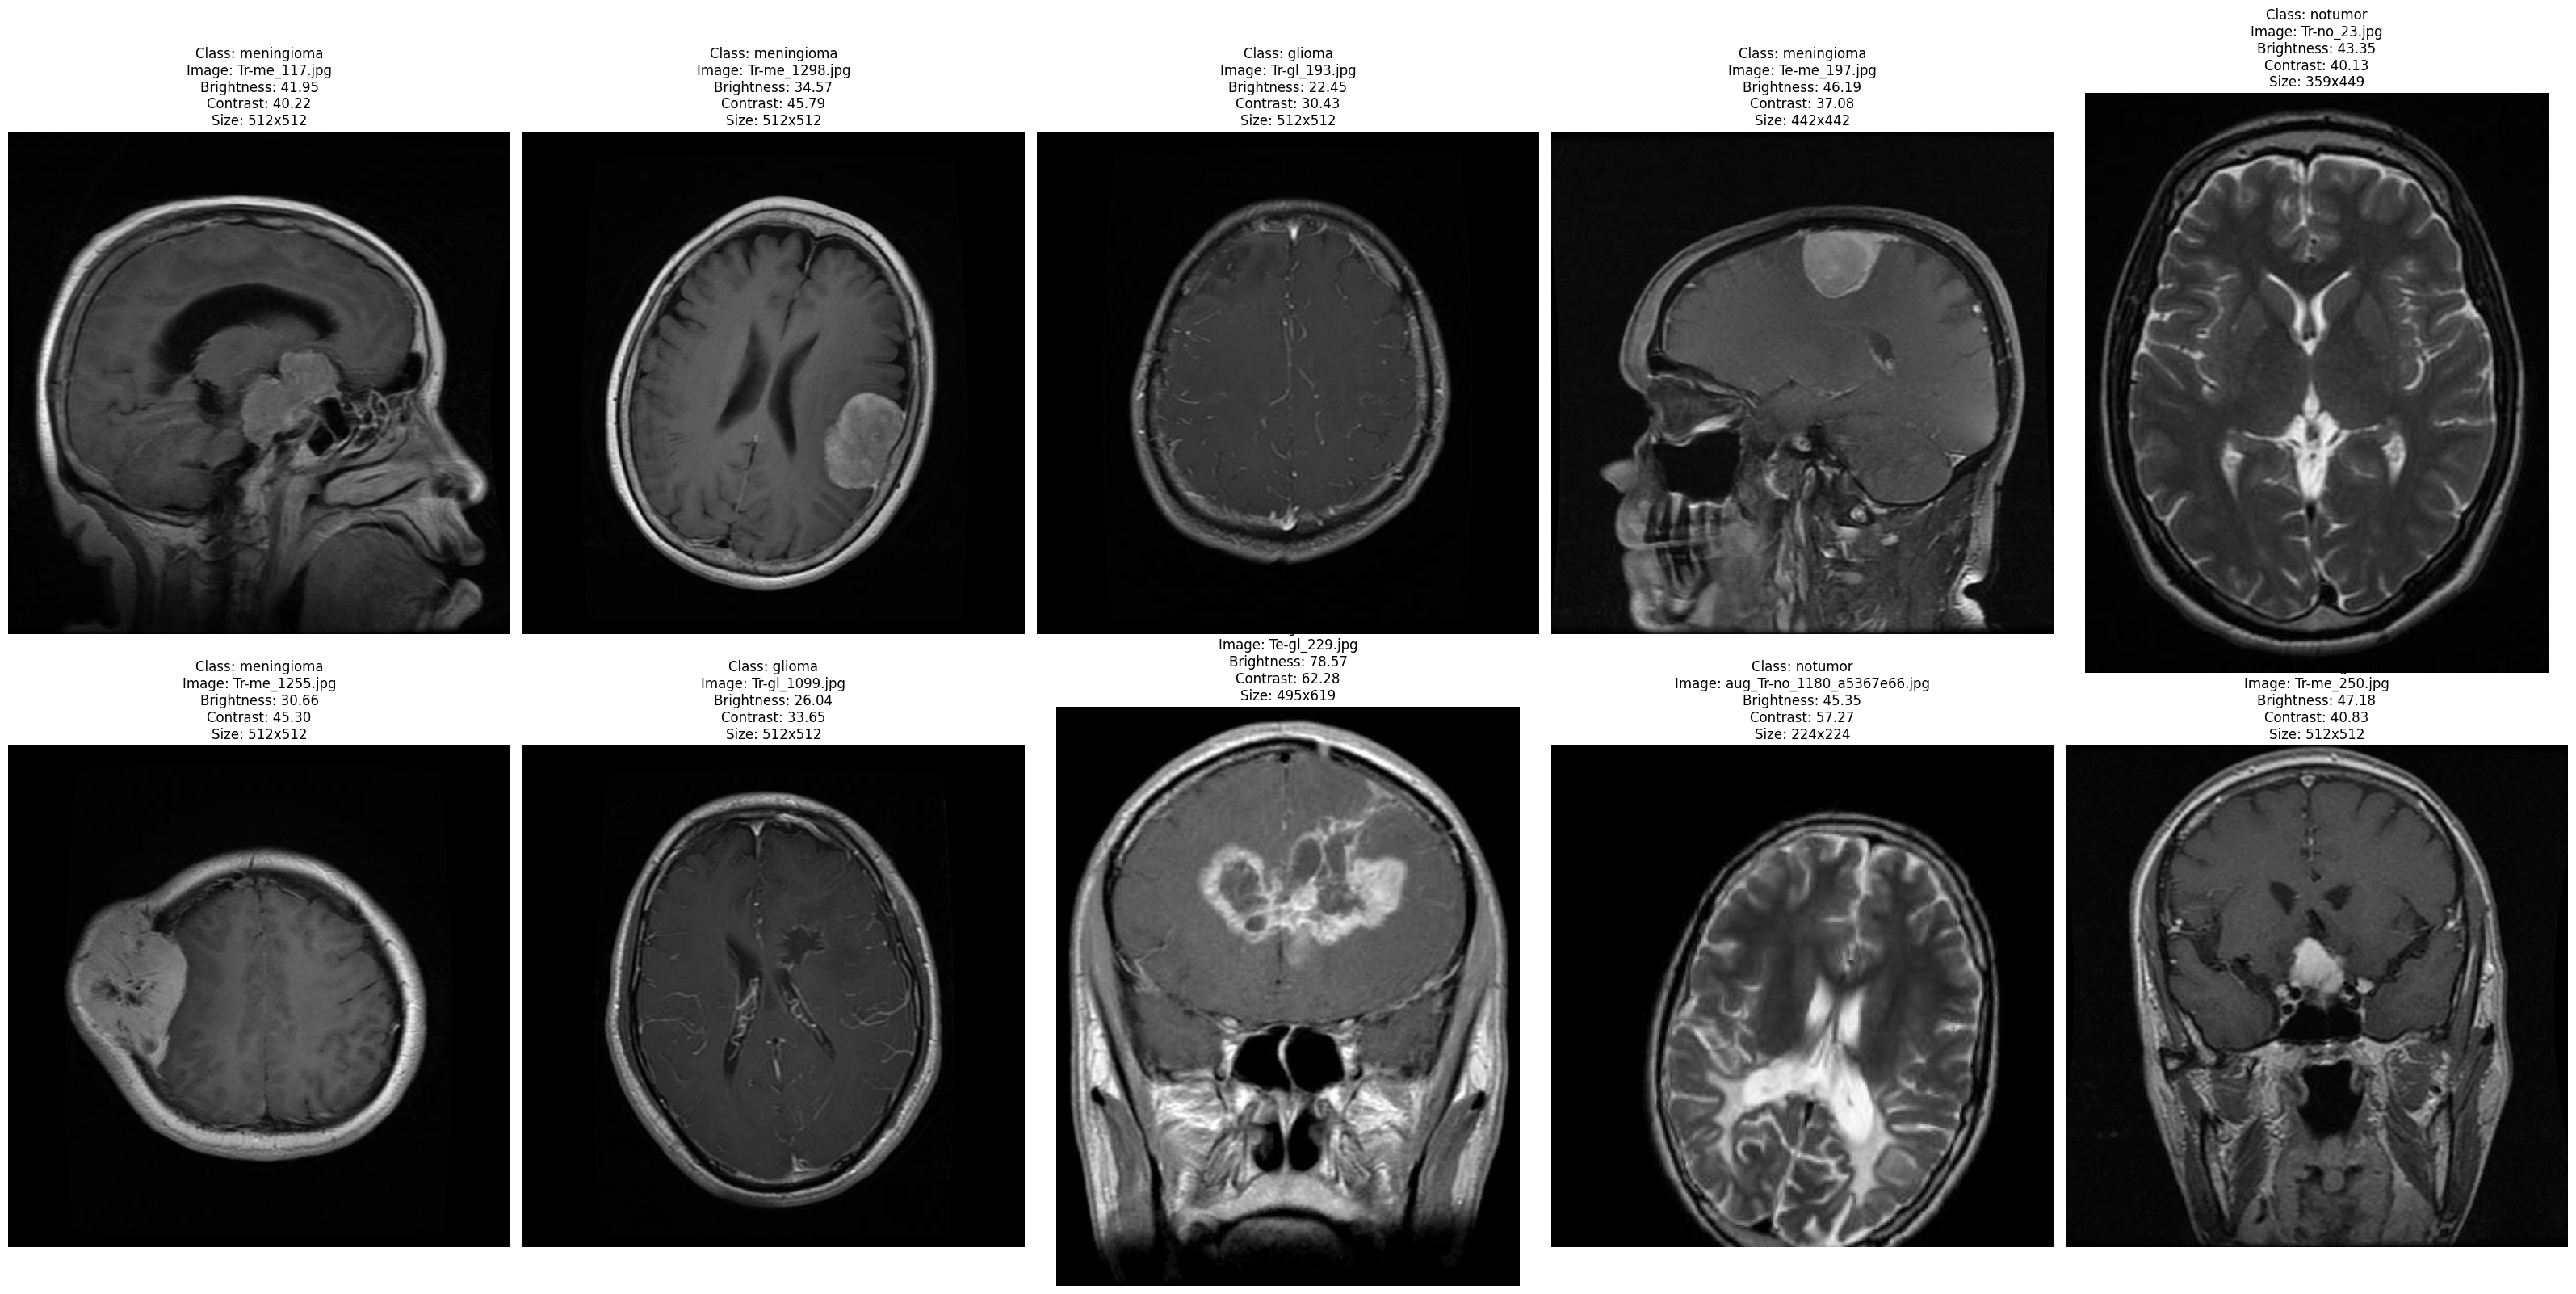

In [15]:
# I randomly selected 10 images from the dataset for inspection
sample_df = df.sample(n=10, random_state=42)

plt.figure(figsize=(32, 16))

# I evaluated brightness, contrast, and size for each sampled image
for i, (cls, img_name, full_path) in enumerate(sample_df.values):
    with Image.open(full_path) as img:
        img_rgb = img.convert("RGB")

        stat = ImageStat.Stat(img_rgb)
        brightness = stat.mean[0]
        contrast = stat.stddev[0]

        width, height = img.size
        print(f"Image: {img_name} | Class: {cls} | Size: {width}x{height} | Brightness: {brightness:.1f} | Contrast: {contrast:.1f}")

        # I displayed the image along with its computed properties
        plt.subplot(2, 5, i + 1)
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title(
            f"Class: {cls}\n"
            f"Image: {img_name}\n"
            f"Brightness: {brightness:.2f}\n"
            f"Contrast: {contrast:.2f}\n"
            f"Size: {width}x{height}"
        )

plt.tight_layout()
plt.show()

# Random Dataset Sample Visualization (Sanity Check)

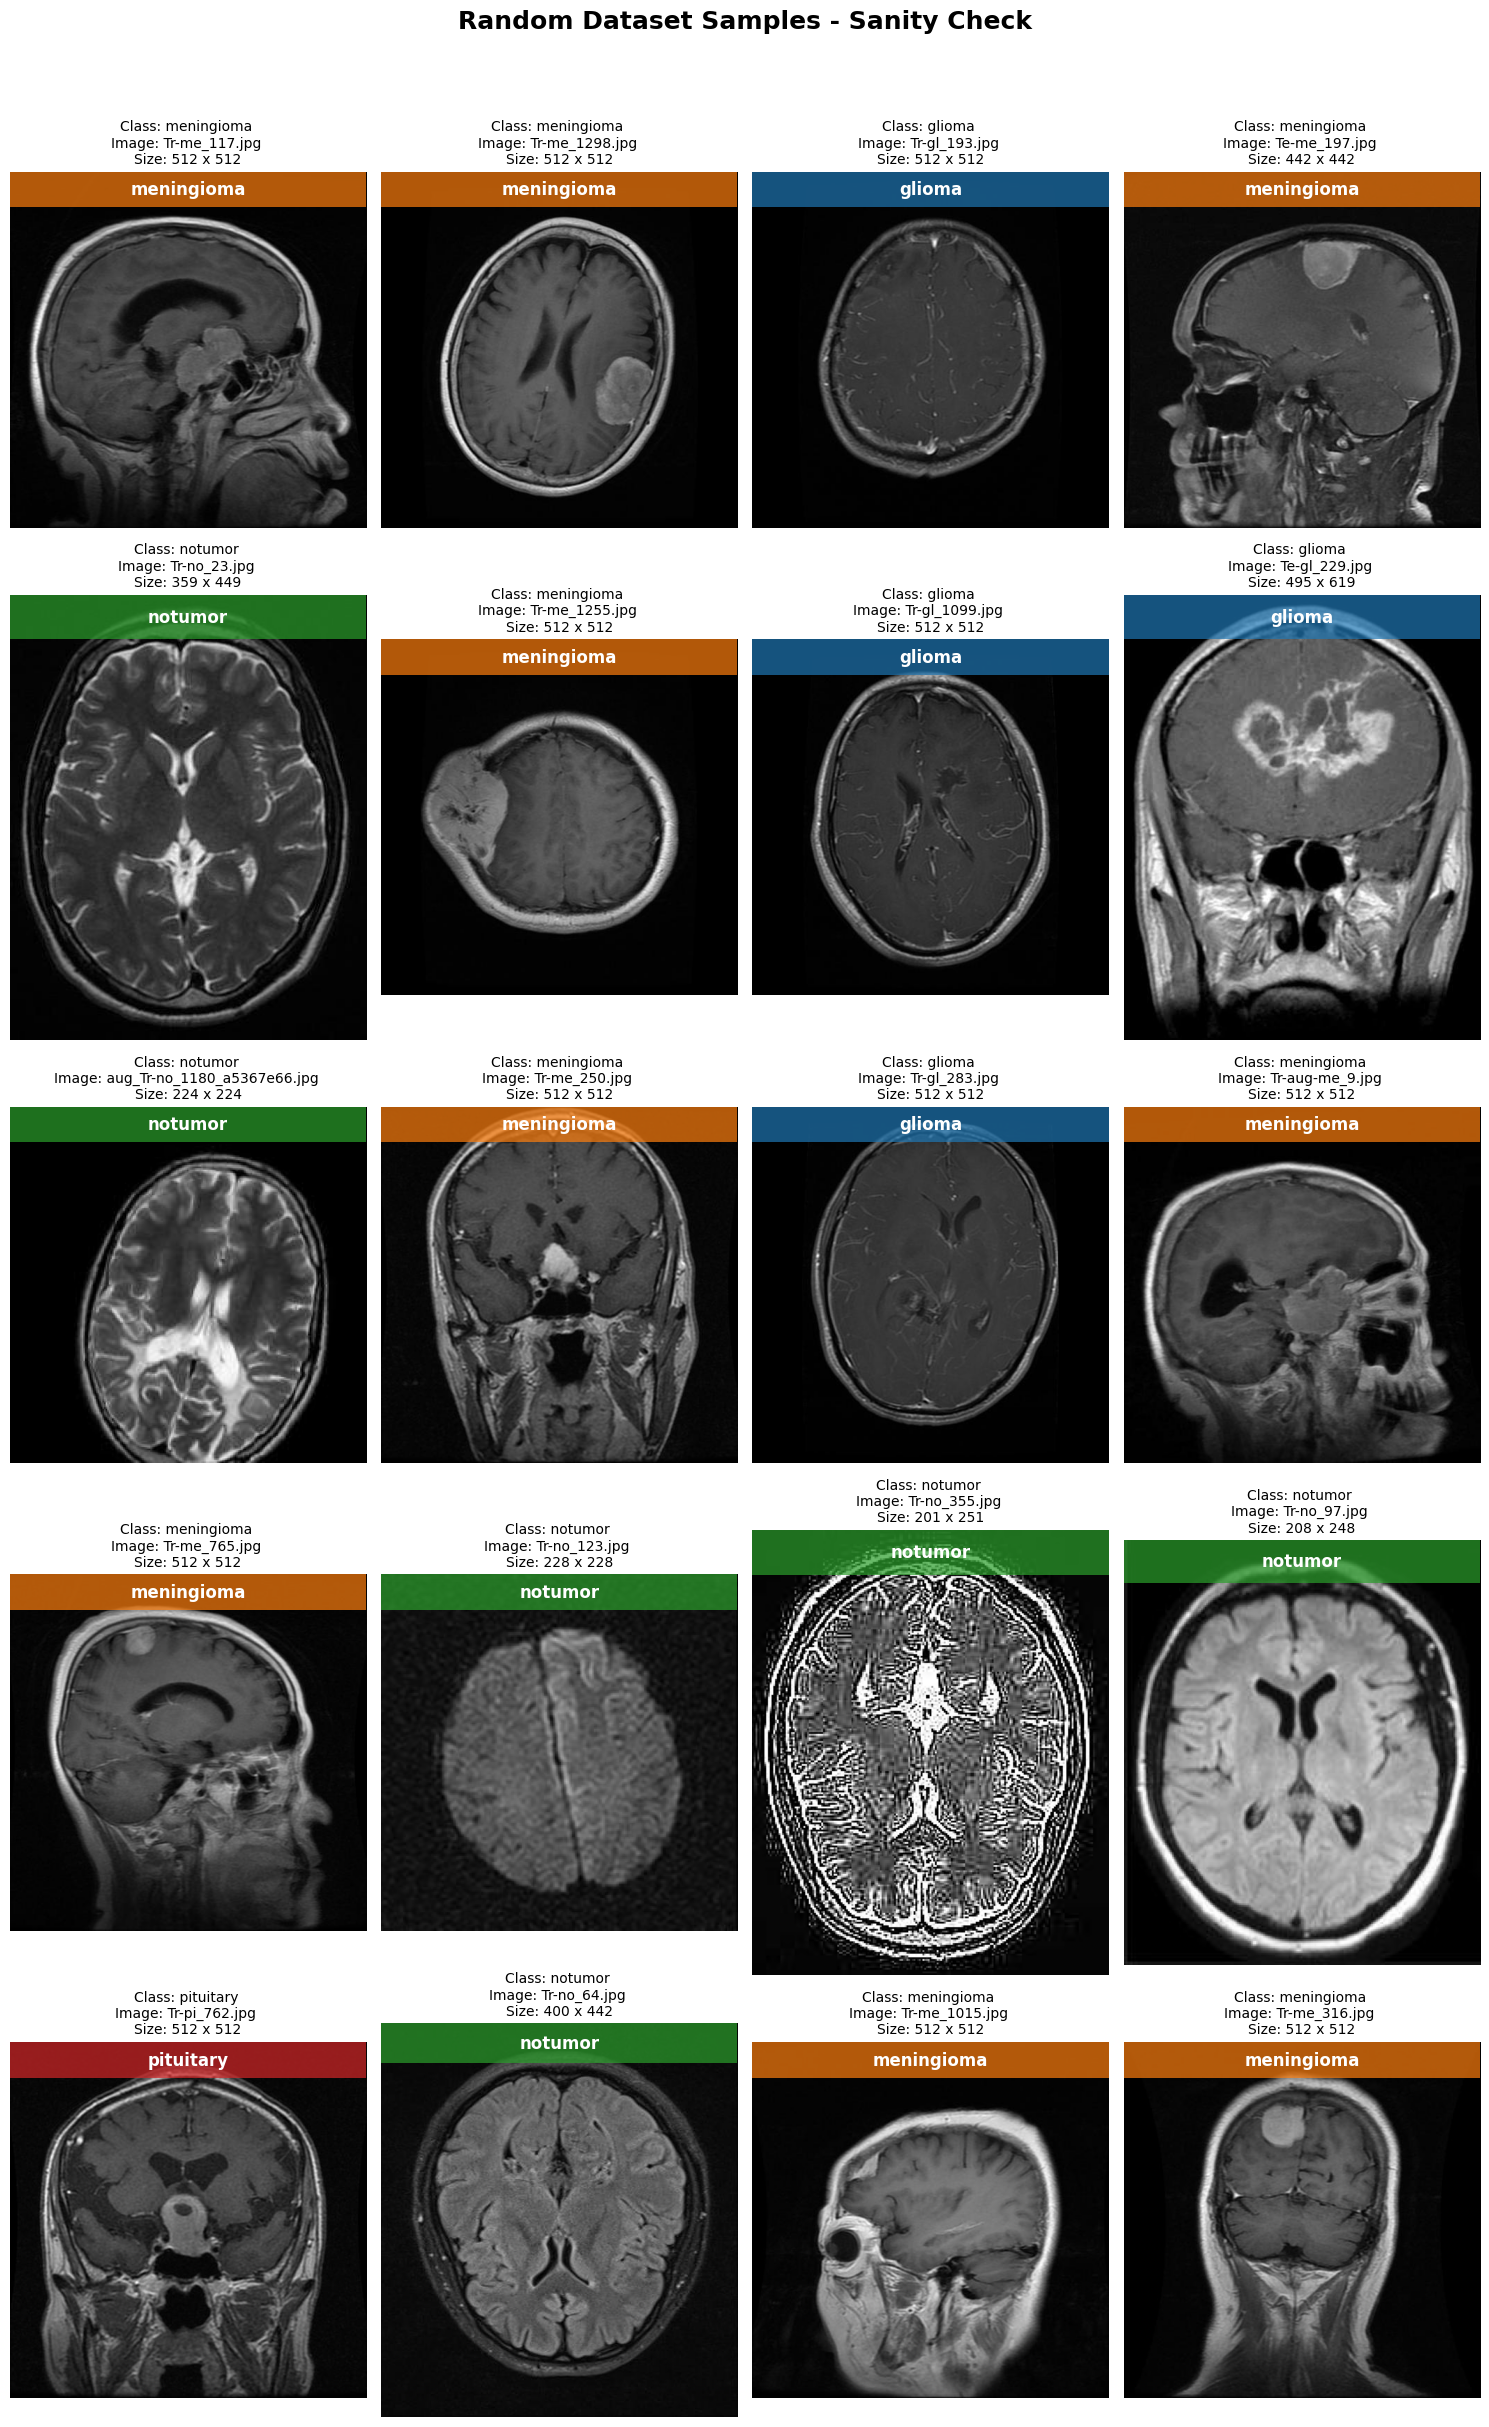

In [16]:
# I randomly selected 20 images to visually verify dataset correctness
num_samples = 20
sample_df = df.sample(num_samples, random_state=42)

# I prepared class labels and color mapping for visualization
classes = sorted(df['class'].unique())
colors = plt.cm.tab10.colors

# I defined grid layout for displaying images
cols = 4
rows = num_samples // cols + int(num_samples % cols > 0)

# I created a figure to plot sample images
plt.figure(figsize=(15, 5 * rows))

for idx, (cls, img_name, full_path) in enumerate(sample_df.values):
    with Image.open(full_path) as img:
        img_rgb = img.convert("RGB")
        ax = plt.subplot(rows, cols, idx + 1)
        ax.imshow(img_rgb)
        ax.axis('off')

        # I added image information in the title
        ax.set_title(
            f"Class: {cls} \nImage: {img_name} \nSize: {img.width} x {img.height}",
            fontsize=10
        )

        # I added a colored label bar indicating the class
        label_height = 0.1
        label_width = 1.0

        rect = patches.Rectangle(
            (0, 1 - label_height), label_width, label_height,
            transform=ax.transAxes,
            linewidth=0,
            edgecolor=None,
            facecolor=colors[classes.index(cls) % len(colors)],
            alpha=0.7
        )
        ax.add_patch(rect)

        # I placed class name text over the colored label
        ax.text(
            0.5, 1 - label_height / 2,
            cls,
            transform=ax.transAxes,
            fontsize=12,
            color="white",
            fontweight="bold",
            va="center",
            ha="center"
        )

# I added figure title and adjusted layout
plt.suptitle("Random Dataset Samples - Sanity Check", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Data Quality Checks and Duplicate Detection

In [17]:
# I checked for missing values in each dataframe column
print("Missing values per column: ")
print(df.isnull().sum())

# I checked for duplicate rows in the dataset
duplicate_names = df.duplicated().sum()
print(f"\nNumber of duplicate files: {duplicate_names}")

# I identified duplicate file names
duplicate_names = df[df.duplicated(subset = ['image'], keep = False)]
print(f"Duplicate file names: {len(duplicate_names)}")

# I created a hash function to detect identical images even with different filenames
def get_hash(file_path):
    with open(file_path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

# I generated hash values for all images
df['file_hash'] = df['full_path'].apply(get_hash)

# I detected duplicate images based on file content
duplicate_hashes = df[df.duplicated(subset = ['file_hash'], keep = False)]
print(f"Duplicate image files: {len(duplicate_hashes)}")

# I noted that duplicates were removed only from dataframe (not actual directory)
# df_unique = df.drop_duplicates(subset='file_hash', keep='first')
# print(f"After removing duplicates, unique images: {len(df_unique)}")

# I checked distribution of image file extensions
df['extenstion'] = df['image'].apply(lambda x: Path(x).suffix.lower())
print("File type counts: ")
print(df['extenstion'].value_counts())

# I analyzed resolution statistics per class
df['Width'] = sizes_df['Width']
df['Height'] = sizes_df['Height']
print(df.groupby('class')[['Width', 'Height']].agg(['min', 'max', 'mean']))

# I calculated class balance statistics
class_summary = df['class'].value_counts(normalize = False).to_frame('Count')
class_summary['Percentage %'] = round((class_summary['Count'] / len(df)) * 100, 2)
print(class_summary)

Missing values per column: 
class        0
image        0
full_path    0
dtype: int64

Number of duplicate files: 0
Duplicate file names: 0
Duplicate image files: 340
File type counts: 
extenstion
.jpg    8000
Name: count, dtype: int64
            Width                     Height                    
              min     max        mean    min     max        mean
class                                                           
glioma      175.0   640.0  505.151000  167.0   665.0  506.313500
meningioma  150.0  1275.0  451.054000  168.0  1427.0  455.084500
notumor     150.0  1375.0  368.456000  168.0  1446.0  376.377500
pituitary   201.0  1338.0  512.049167  202.0  1304.0  511.769167
            Count  Percentage %
class                          
glioma       2000          25.0
meningioma   2000          25.0
notumor      2000          25.0
pituitary    2000          25.0


# Data Cleaning Process

In [18]:
# I checked for corrupted image files to ensure dataset quality
corrupted_files = []

for file_path in df['full_path']:
    try:
        # I attempted to open each image and verify its integrity
        with Image.open(file_path) as img:
            img.verify()  # I verified whether the file was readable and not broken
    except (UnidentifiedImageError, OSError):
        # If the image failed to load, I considered it corrupted
        corrupted_files.append(file_path)

print(f"Found {len(corrupted_files)} corrupted images.")

# I removed corrupted files from the dataframe
if corrupted_files:
    df = df[~df['full_path'].isin(corrupted_files)].reset_index(drop=True)
    print("Corrupted files removed.")


# I performed outlier detection based on image resolution statistics
width_mean = sizes_df['Width'].mean()
width_std = sizes_df['Width'].std()
height_mean = sizes_df['Height'].mean()
height_std = sizes_df['Height'].std()

# I identified images whose width or height deviated beyond 3 standard deviations
outliers = df[
    (df['Width'] > width_mean + 3 * width_std) |
    (df['Width'] < width_mean - 3 * width_std) |
    (df['Height'] > height_mean + 3 * height_std) |
    (df['Height'] < height_mean - 3 * height_std)
]
print(f"Found {len(outliers)} resolution outliers.")


# I evaluated image brightness and contrast without loading all images into memory
too_dark = []
too_bright = []
blank_or_gray = []

# I defined thresholds to detect unusable images
dark_threshold = 30      # Below this value, I considered the image too dark
bright_threshold = 225   # Above this value, I considered the image too bright
low_contrast_threshold = 5  # Very low contrast indicated blank or near-gray images

for idx, file_path in enumerate(df['full_path']):
    try:
        # I opened the image and converted it to grayscale for statistical analysis
        with Image.open(file_path).convert('RGB') as img:
            gray = img.convert('L')
            stat = ImageStat.Stat(gray)

            # I calculated brightness (mean intensity) and contrast (standard deviation)
            brightness = stat.mean[0]
            contrast = stat.stddev[0]

            # I categorized problematic images based on thresholds
            if brightness < dark_threshold:
                too_dark.append(file_path)
            elif brightness > bright_threshold:
                too_bright.append(file_path)
            elif contrast < low_contrast_threshold:
                blank_or_gray.append(file_path)

    except Exception as e:
        # If an error occurred while reading, I skipped that image
        print(f"Skipping {file_path} due to error: {e}")

print(f"Too dark images: {len(too_dark)}")
print(f"Too bright images: {len(too_bright)}")
print(f"Blank/gray images: {len(blank_or_gray)}")

# Optionally, I could remove overly bright or blank images if needed
# df = df[~df['full_path'].isin(too_bright + blank_or_gray)].reset_index(drop=True)

# I intentionally avoided performing enhancements here.
# Instead, I planned to apply brightness and contrast adjustments later inside the tf.data pipeline.

Found 0 corrupted images.
Found 49 resolution outliers.
Too dark images: 949
Too bright images: 0
Blank/gray images: 0


# Label Consistency Verification

In [19]:
# I specified the path to the extracted dataset directory
dataset_root = "/content/brain_data_balanced"

# I checked for mislabeled images by comparing dataframe labels with folder names
mismatches = []
for i, row in df.iterrows():
    # I extracted the folder name from the image file path
    folder_name = os.path.basename(os.path.dirname(row["full_path"]))

    # I compared the assigned class label with the folder name
    if row["class"] != folder_name:
        # If they did not match, I recorded the mismatch
        mismatches.append((row["full_path"], row["class"], folder_name))

print(f"Found {len(mismatches)} mislabeled images (class vs folder mismatch).")

# I compared the set of classes in the dataframe with the actual folders in the dataset
classes_in_df = set(df["class"].unique())
folders_in_fs = {f for f in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, f))}

# I identified labels present in the dataframe but missing in folders
print("Classes in DF but not in folders:", classes_in_df - folders_in_fs)

# I identified folders present in the dataset but missing in the dataframe labels
print("Folders in FS but not in DF:", folders_in_fs - classes_in_df)

Found 0 mislabeled images (class vs folder mismatch).
Classes in DF but not in folders: set()
Folders in FS but not in DF: set()


# File Naming and Path Integrity Validation

In [20]:
# I created a function to check potential file naming and path related issues
def check_file_naming_issues(df):
    issues = {"invalid_chars": [], "spaces": [], "long_paths": [], "case_conflicts": [], "duplicate_names_across_classes": []}

    seen_names = {}

    for _, row in df.iterrows():
        fpath = row["full_path"]              # I read the complete file path
        fname = os.path.basename(fpath)       # I extracted only the filename
        cls = row["class"]                    # I stored the corresponding class label

        # I checked for invalid characters that are restricted in some operating systems (e.g., Windows)
        if re.search(r'[<>:"/\\|?*]', fname):
            issues["invalid_chars"].append(fpath)

        # I checked for unwanted spaces such as double spaces or leading/trailing spaces
        if "  " in fname or fname.startswith(" ") or fname.endswith(" "):
            issues["spaces"].append(fpath)

        # I checked whether the full path length exceeded the safe limit (255 characters)
        if len(fpath) > 255:
            issues["long_paths"].append(fpath)

        # I detected case conflicts (e.g., Tumor.jpg vs tumor.jpg in different classes)
        lower_name = fname.lower()
        if lower_name in seen_names and seen_names[lower_name] != cls:
            issues["case_conflicts"].append((fpath, seen_names[lower_name]))
        else:
            seen_names[lower_name] = cls

    # I checked duplicate filenames appearing across multiple classes
    duplicates = df.groupby(df["full_path"].apply(os.path.basename))["class"].nunique()
    duplicates = duplicates[duplicates > 1].index.tolist()
    for dup in duplicates:
        dup_paths = df[df["full_path"].str.endswith(dup)]["full_path"].tolist()
        issues["duplicate_names_across_classes"].extend(dup_paths)

    return issues


# I executed the file naming validation check
naming_issues = check_file_naming_issues(df)

# I printed a summary of detected issues and previewed the first 10 affected files
for issue_type, files in naming_issues.items():
    print(f"\n{issue_type.upper()} ({len(files)})")
    for f in files[:10]:  # I displayed only a sample for quick inspection
        print(f)


INVALID_CHARS (0)

SPACES (0)

LONG_PATHS (0)

CASE_CONFLICTS (0)

DUPLICATE_NAMES_ACROSS_CLASSES (0)


# Data Pre-Processing Process

# Image Preprocessing and Data Augmentation Pipeline

In [21]:
# I prepared lookup tables (optional) to identify dark and bright images inside the TensorFlow pipeline
# dark_table = tf.lookup.StaticHashTable(
#     tf.lookup.KeyValueTensorInitializer(
#         keys=tf.constant([str(x) for x in too_dark], dtype=tf.string),
#         values=tf.constant([1] * len(too_dark), dtype=tf.int32)
#     ),
#     default_value=0
# )

# bright_table = tf.lookup.StaticHashTable(
#     tf.lookup.KeyValueTensorInitializer(
#         keys=tf.constant([str(x) for x in too_bright], dtype=tf.string),
#         values=tf.constant([1] * len(too_bright), dtype=tf.int32)
#     ),
#     default_value=0
# )

def preprocess_image(path, target_size=(512, 512), augment=True):

    # I read the image file from disk
    img = tf.io.read_file(path)

    # I decoded the image and forced it into 3 channels (RGB)
    img = tf.image.decode_image(img, channels=3)
    img.set_shape([None, None, 3])

    # I resized the image to a uniform resolution required by the model
    img = tf.image.resize(img, target_size)

    # I normalized pixel values to the range [0,1]
    img = tf.cast(img, tf.float32) / 255.0


    # (Optional Enhancement Section — kept for controlled preprocessing experiments)
    # I checked whether the image belonged to dark or bright categories
    # is_dark = dark_table.lookup(path)
    # is_bright = bright_table.lookup(path)

    # I enhanced dark images by increasing brightness and contrast
    # img = tf.cond(
    #     tf.equal(is_dark, 1),
    #     lambda: tf.image.adjust_brightness(img, 0.2),
    #     lambda: img
    # )
    # img = tf.cond(
    #     tf.equal(is_dark, 1),
    #     lambda: tf.image.adjust_contrast(img, 1.5),
    #     lambda: img
    # )

    # I reduced brightness for overly bright images
    # img = tf.cond(
    #     tf.equal(is_bright, 1),
    #     lambda: tf.image.adjust_brightness(img, -0.2),
    #     lambda: img
    # )
    # img = tf.cond(
    #     tf.equal(is_bright, 1),
    #     lambda: tf.image.adjust_contrast(img, 1.2),
    #     lambda: img
    # )


    # I applied data augmentation to improve model generalization
    if augment:
        img = tf.image.random_flip_left_right(img)   # horizontal flip
        img = tf.image.random_flip_up_down(img)      # vertical flip
        img = tf.image.random_brightness(img, max_delta=0.1)  # brightness variation
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)  # contrast variation

    # I ensured pixel values remained within valid range
    img = tf.clip_by_value(img, 0.0, 1.0)

    return img


# Alternative probabilistic augmentation strategy
# I could optionally apply augmentations to only a subset of images per epoch

# if augment:
#     if tf.random.uniform(()) < 0.1:
#         img = tf.image.random_flip_left_right(img)
#     if tf.random.uniform(()) < 0.1:
#         img = tf.image.random_flip_up_down(img)
#     if tf.random.uniform(()) < 0.2:
#         img = tf.image.random_brightness(img, max_delta=0.1)
#     if tf.random.uniform(()) < 0.2:
#         img = tf.image.random_contrast(img, 0.9, 1.1)

# Class Label Encoding

In [22]:
# I initialized a label encoder to convert categorical class names into numerical labels
le = LabelEncoder()

# I transformed the class column into encoded numerical values required for model training
df['label_encoded'] = le.fit_transform(df['class'])

# I displayed the discovered class names in alphabetical order
print("Classes found:", le.classes_)

# I previewed the mapping between original class names and encoded labels
print(df[['class', 'label_encoded']].head())

Classes found: ['glioma' 'meningioma' 'notumor' 'pituitary']
    class  label_encoded
0  glioma              0
1  glioma              0
2  glioma              0
3  glioma              0
4  glioma              0


# Dataset Splitting and TensorFlow Data Pipeline Preparation

Dataset sizes:
Train: 6480 images
Validation: 720 images
Test: 800 images
--------------------------------------------------
Train labels sample: 6804    3
3438    1
4242    2
7094    3
5582    2
3644    1
2147    1
5351    2
2057    1
1946    0
Name: label_encoded, dtype: int64
Validation labels sample: 2400    1
5479    2
6596    3
346     0
4500    2
5635    2
4308    2
6679    3
2958    1
1643    0
Name: label_encoded, dtype: int64
Test labels sample: 3661    1
3367    1
2986    1
5424    2
6746    3
7813    3
7499    3
5113    2
6941    3
4789    2
Name: label_encoded, dtype: int64
Image dtype: <dtype: 'float32'>
Min pixel value: 0.0
Max pixel value: 0.9149023
Label: 2


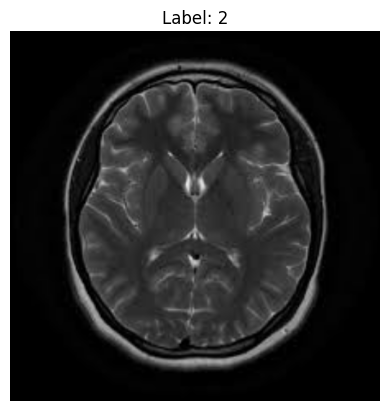

---------------------------------------------------
Number of Classes:  4


In [23]:
AUTOTUNE = tf.data.AUTOTUNE
batch_size = 32

# I split the dataset into training+validation and test sets (10% reserved for testing)
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    df['full_path'], df['label_encoded'],
    test_size=0.1, random_state=42, stratify=df['label_encoded']
)

# I further split the training portion into training and validation sets (10% of remaining for validation)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size=0.1, random_state=42, stratify=train_val_labels
)


# I defined a function to load and preprocess images (without augmentation for validation/test)
def load_and_preprocess(path, label):
    return preprocess_image(path, augment=False), label


# I created the training dataset pipeline
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(buffer_size=len(train_paths))  # I shuffled the dataset to prevent learning order bias
train_ds = train_ds.map(lambda x, y: (preprocess_image(x, augment=False), y),
                        num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(batch_size).prefetch(AUTOTUNE)  # I batched and prefetched for performance


# I created the validation dataset pipeline (no augmentation)
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(batch_size).cache("/tmp/val_cache").prefetch(AUTOTUNE)


# I created the test dataset pipeline (no augmentation)
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(batch_size).cache("/tmp/test_cache").prefetch(AUTOTUNE)


# I performed debugging and sanity checks
print("Dataset sizes:")
print(f"Train: {len(train_paths)} images")
print(f"Validation: {len(val_paths)} images")
print(f"Test: {len(test_paths)} images")
print("--------------------------------------------------")
print("Train labels sample:", train_labels[:10])
print("Validation labels sample:", val_labels[:10])
print("Test labels sample:", test_labels[:10])


# I inspected one processed image to verify normalization and correctness
for image_batch, label_batch in train_ds.take(1):
    image = image_batch[0]
    label = label_batch[0]
    print("Image dtype:", image.dtype)
    print("Min pixel value:", tf.reduce_min(image).numpy())
    print("Max pixel value:", tf.reduce_max(image).numpy())
    print("Label:", label.numpy())

    plt.imshow(image.numpy())
    plt.title(f"Label: {label.numpy()}")
    plt.axis('off')
    plt.show()

print("---------------------------------------------------")
print("Number of Classes: ", len(le.classes_))

# Global Pixel Value Normalization Verification

In [24]:
# I verified normalization across the entire training dataset

all_mins, all_maxs = [], []

# I iterated through all batches in the training dataset
for image_batch, _ in train_ds:
    # I recorded the minimum pixel value in the batch
    all_mins.append(np.min(image_batch.numpy()))

    # I recorded the maximum pixel value in the batch
    all_maxs.append(np.max(image_batch.numpy()))

# I computed the global minimum and maximum pixel values
print("Global min pixel value:", np.min(all_mins))
print("Global max pixel value:", np.max(all_maxs))

Global min pixel value: 0.0
Global max pixel value: 1.0


# Input Shape Verification for Model Compatibility

In [25]:
# I inspected a batch from the training dataset to confirm correct tensor dimensions
for image_batch, label_batch in train_ds.take(1):

    # I printed the shape of the full image batch
    print("Image batch shape:", image_batch.shape)

    # I printed the shape of the corresponding label batch
    print("Label batch shape:", label_batch.shape)

    # I extracted the shape of a single input image for model input configuration
    input_shape = image_batch.shape[1:]
    print("Single image shape:", input_shape)

    break

Image batch shape: (32, 512, 512, 3)
Label batch shape: (32,)
Single image shape: (512, 512, 3)


# Model Loading

# InceptionV3 Model Initialization and Layer Freezing

In [26]:
# I loaded the InceptionV3 model with the specified input shape,
# using pretrained ImageNet weights and excluding the top classification layer
inception = InceptionV3(input_shape=input_shape, weights='imagenet', include_top=False)

# I froze the pretrained layers so that the existing weights were not updated during training
for layer in inception.layers:
    layer.trainable = False

# I printed the total number of target classes identified by the label encoder
print("Number of Classes: ", len(le.classes_))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of Classes:  4


# Custom Classification Layer Construction and Model Architecture

In [27]:
# I applied a Global Average Pooling layer to reduce the spatial dimensions
# of the feature maps obtained from the InceptionV3 base model
x = GlobalAveragePooling2D()(inception.output)

# I added a fully connected dense layer with 512 neurons and ReLU activation
# to learn high-level feature representations
x = Dense(512, activation='relu')(x)

# I applied a dropout layer with a rate of 0.5 to reduce overfitting
# by randomly disabling neurons during training
x = Dropout(0.5)(x)

# I created the final output layer using softmax activation
# to perform multi-class classification based on the number of classes
prediction = Dense(len(le.classes_), activation='softmax')(x)

# I created the final model by connecting the InceptionV3 input with the prediction output layer
model = Model(inputs=inception.input, outputs=prediction)

# I displayed the architecture and summary of the constructed model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 255, 255,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 255, 255,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 255, 255,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 253, 253,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 253, 253,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 253, 253,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 253, 253,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 253, 253,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 253, 253,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 126, 126,  │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 126, 126,  │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 126, 126,  │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 126, 126,  │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 124, 124,  │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 124, 124,  │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 124, 124,  │          0 │ batch_normalizat

 Total params: 22,853,924 (87.18 MB)

 Trainable params: 1,051,140 (4.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

# Model Compilation with Accuracy and Macro F1-Score

In [28]:
# I defined a custom function to calculate the Macro F1-score
import tensorflow as tf
from tensorflow.keras import backend as K

def macro_f1(y_true, y_pred):
    y_pred = tf.argmax(y_pred, axis=1)
    y_true = tf.cast(y_true, tf.int64)

    # I calculated precision
    precision = tf.reduce_mean(tf.cast(tf.equal(y_true, y_pred), tf.float32))

    # I calculated recall
    recall = precision

    # I computed the F1-score using the harmonic mean of precision and recall
    f1_score = 2 * (precision * recall) / (precision + recall + K.epsilon())

    return f1_score

# I compiled the model by specifying the loss function, optimizer,
# and evaluation metrics including accuracy and Macro F1-score
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy', macro_f1]
)

# Model Feature Extraction


In [30]:
# I defined training callbacks to improve model training and prevent overfitting.
callbacks = [

    # I applied EarlyStopping to stop training automatically when validation loss stopped improving.
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),

    # I saved the best performing model during training based on the lowest validation loss.
    ModelCheckpoint("best_model.keras", save_best_only=True, monitor='val_loss', verbose=1),

    # I used ReduceLROnPlateau to reduce the learning rate when validation loss stopped improving.
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
]

# I trained the model using the training dataset and validated it on the validation dataset.
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8160 - loss: 0.4809 - macro_f1: 0.8160
Epoch 1: val_loss improved from None to 0.37318, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
203/203 ━━━━━━━━━━━━━━━━━━━━ 34s 166ms/step - accuracy: 0.8252 - loss: 0.4638 - macro_f1: 0.8253 - val_accuracy: 0.8556 - val_loss: 0.3732 - val_macro_f1: 0.8573 - learning_rate: 0.0010
Epoch 2/5
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.8368 - loss: 0.4238 - macro_f1: 0.8368
Epoch 2: val_loss improved from 0.37318 to 0.32926, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
203/203 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.8465 - loss: 0.4083 - macro_f1: 0.8462 - val_accuracy: 0.8889 - val_loss: 0.3293 - val_macro_f1: 0.8899 - learning_rate: 0.0010
Epoch 3/5
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8641 - loss: 0.3872 - macro_f1: 0.8641
Epoch 3: val_loss improved from 0.32926